## Optimization Implementation

Accuracy: 100.00%
Final loss: 3.7514


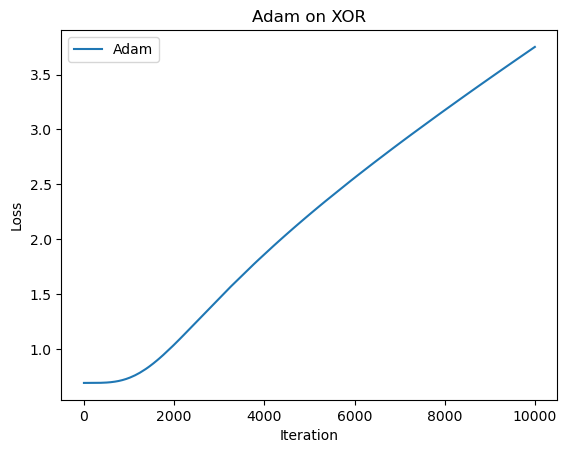

In [ ]:
# importing the libraries
import numpy as np
import matplotlib.pyplot as plt

# data
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])

# model
class NeuralNetworkAdam:
    def __init__(self, lr=0.001, n_iter=10000,
                 beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.lr = lr
        self.n_iter = n_iter
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.loss_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def relu(self, z):
        return np.maximum(0, z)

    def relu_derivative(self, z):
        return (z > 0).astype(float)

    def initialize(self):
        np.random.seed(42)
        self.W1 = np.random.randn(2, 4) * 0.01
        self.b1 = np.zeros(4)
        self.W2 = np.random.randn(4, 1) * 0.01
        self.b2 = np.zeros(1)

        # adam moment estimates, one per parameter
        self.mW1 = np.zeros_like(self.W1)
        self.vW1 = np.zeros_like(self.W1)
        self.mb1 = np.zeros_like(self.b1)
        self.vb1 = np.zeros_like(self.b1)
        self.mW2 = np.zeros_like(self.W2)
        self.vW2 = np.zeros_like(self.W2)
        self.mb2 = np.zeros_like(self.b2)
        self.vb2 = np.zeros_like(self.b2)

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.relu(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def backward(self, X, y):
        n = len(y)
        delta2 = self.a2 - y.reshape(-1, 1)
        dW2 = (1/n) * self.a1.T @ delta2
        db2 = (1/n) * np.sum(delta2, axis=0)
        delta1 = delta2 @ self.W2.T * self.relu_derivative(self.z1)
        dW1 = (1/n) * X.T @ delta1
        db1 = (1/n) * np.sum(delta1, axis=0)
        return dW1, db1, dW2, db2

    def adam_update(self, param, grad, m, v, t):
        m = self.beta1 * m + (1 - self.beta1) * grad
        v = self.beta2 * v + (1 - self.beta2) * grad**2
        m_hat = m / (1 - self.beta1**t)
        v_hat = v / (1 - self.beta2**t)
        param -= self.lr * m_hat / (np.sqrt(v_hat) + self.epsilon)
        return param, m, v

    def fit(self, X, y):
        self.initialize()
        for t in range(1, self.n_iter + 1):
            self.forward(X)
            dW1, db1, dW2, db2 = self.backward(X, y)

            # adam updated for each parameter
            self.W1, self.mW1, self.vW1 = self.adam_update(
                self.W1, dW1, self.mW1, self.vW1, t)
            self.b1, self.mb1, self.vb1 = self.adam_update(
                self.b1, db1, self.mb1, self.vb1, t)
            self.W2, self.mW2, self.vW2 = self.adam_update(
                self.W2, dW2, self.mW2, self.vW2, t)
            self.b2, self.mb2, self.vb2 = self.adam_update(
                self.b2, db2, self.mb2, self.vb2, t)

            loss = -np.mean(y * np.log(self.a2 + 1e-8) +
                           (1-y) * np.log(1-self.a2 + 1e-8))
            self.loss_history.append(loss)

# training
model = NeuralNetworkAdam(lr=0.001, n_iter=10000)
model.fit(X_xor, y_xor)

a2 = model.forward(X_xor)
predictions = (a2 >= 0.5).astype(int).flatten()
accuracy = np.mean(predictions == y_xor)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Final loss: {model.loss_history[-1]:.4f}")

# plotting
plt.plot(model.loss_history, label='Adam')
plt.title('Adam on XOR')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.show()